In [1]:
# VGG 16 모델 불러오기
import keras

vggnet = keras.applications.VGG16()

2026-04-10 14:52:08.904111: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 14:52:08.929027: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 14:52:08.929055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 14:52:08.929802: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 14:52:08.934231: I tensorflow/core/platform/cpu_feature_guar

:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-10 14:52:10.390747: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4732 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


553467096/553467096 [==============================] - 17s 0us/step


In [6]:
from PIL import Image

dog_png = Image.open('images/dog.png')

In [7]:
!pip install pillow

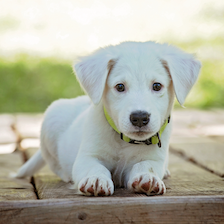

In [8]:
display(dog_png)

In [9]:
import numpy as np

In [12]:
dog_array= np.array(dog_png)
dog_array.shape

(224, 224, 3)

In [18]:
from keras.applications import vgg16

In [28]:
vgg_prep_dog = vgg16.preprocess_input(dog_array)

In [31]:
predictions = vggnet.predict(vgg_prep_dog[np.newaxis, :])

2026-04-10 15:16:19.331452: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-10 15:16:19.499041: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 1s 970ms/step


2026-04-10 15:16:20.110756: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [33]:
max(predictions[0])

0.35715333

In [36]:
max_index = np.argmax(predictions[0])
print(max_index,  predictions[0][max_index])

208 0.35715333


In [38]:
import requests

url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
json_data = requests.get(url).json()

In [39]:
print(json_data)

{'0': ['n01440764', 'tench'], '1': ['n01443537', 'goldfish'], '2': ['n01484850', 'great_white_shark'], '3': ['n01491361', 'tiger_shark'], '4': ['n01494475', 'hammerhead'], '5': ['n01496331', 'electric_ray'], '6': ['n01498041', 'stingray'], '7': ['n01514668', 'cock'], '8': ['n01514859', 'hen'], '9': ['n01518878', 'ostrich'], '10': ['n01530575', 'brambling'], '11': ['n01531178', 'goldfinch'], '12': ['n01532829', 'house_finch'], '13': ['n01534433', 'junco'], '14': ['n01537544', 'indigo_bunting'], '15': ['n01558993', 'robin'], '16': ['n01560419', 'bulbul'], '17': ['n01580077', 'jay'], '18': ['n01582220', 'magpie'], '19': ['n01592084', 'chickadee'], '20': ['n01601694', 'water_ouzel'], '21': ['n01608432', 'kite'], '22': ['n01614925', 'bald_eagle'], '23': ['n01616318', 'vulture'], '24': ['n01622779', 'great_grey_owl'], '25': ['n01629819', 'European_fire_salamander'], '26': ['n01630670', 'common_newt'], '27': ['n01631663', 'eft'], '28': ['n01632458', 'spotted_salamander'], '29': ['n01632777', 

In [40]:
json_data[str(max_index)]

['n02099712', 'Labrador_retriever']

In [46]:
vgg16.decode_predictions(predictions)

[[('n02099712', 'Labrador_retriever', 0.35715333),
  ('n02099601', 'golden_retriever', 0.14484678),
  ('n02104029', 'kuvasz', 0.09272483),
  ('n02111500', 'Great_Pyrenees', 0.06917153),
  ('n02106166', 'Border_collie', 0.056703288)]]

In [47]:
from PIL import Image

cat_png = Image.open('images/cat.png')

In [48]:
cat_array= np.array(cat_png)
cat_array.shape

(224, 224, 3)

In [50]:
vgg_prep_cat = vgg16.preprocess_input(cat_array)

In [51]:
predictions = vggnet.predict(vgg_prep_cat[np.newaxis, :])

1/1 [==============================] - 0s 15ms/step


In [52]:
vgg16.decode_predictions(predictions)

[[('n02123045', 'tabby', 0.4328313),
  ('n02124075', 'Egyptian_cat', 0.31123298),
  ('n02123159', 'tiger_cat', 0.2160252),
  ('n02971356', 'carton', 0.0035814904),
  ('n03223299', 'doormat', 0.0031326204)]]

In [70]:
from PIL import Image

hotdog_png = Image.open('images/hotdog.png')

In [71]:
hotdog_array= np.array(hotdog_png)
hotdog_array.shape

(224, 224, 3)

In [72]:
vgg_prep_hd = vgg16.preprocess_input(hotdog_array)

In [73]:
predictions1 = vggnet.predict(vgg_prep_hd[np.newaxis, :])

1/1 [==============================] - 0s 14ms/step


In [74]:
vgg16.decode_predictions(predictions1)

[[('n02099712', 'Labrador_retriever', 0.8336417),
  ('n02100236', 'German_short-haired_pointer', 0.061439782),
  ('n02099849', 'Chesapeake_Bay_retriever', 0.037949257),
  ('n02106550', 'Rottweiler', 0.012956112),
  ('n02093428', 'American_Staffordshire_terrier', 0.012144438)]]

In [75]:
from PIL import Image

harry = Image.open('images/harry.png')

In [76]:
harry_array = np.array(harry)
harry_array.shape

(224, 224, 4)

In [77]:
harry_array = harry_array[:, :, :3]

In [78]:
harry_array.shape

(224, 224, 3)

In [79]:
vgg_prep_harry = vgg16.preprocess_input(harry_array)

In [80]:
predictions2 = vggnet.predict(vgg_prep_harry[np.newaxis, :])

1/1 [==============================] - 0s 13ms/step


In [81]:
vgg16.decode_predictions(predictions2)

[[('n02883205', 'bow_tie', 0.3800746),
  ('n04591157', 'Windsor_tie', 0.06817613),
  ('n10148035', 'groom', 0.032759774),
  ('n03814639', 'neck_brace', 0.03105645),
  ('n04350905', 'suit', 0.030870715)]]

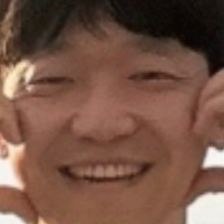

In [82]:
display(harry)